In [1]:
import pandas as pd

mises_citations_df = pd.read_csv("../data/processed/mises_citations.csv")
hayek_citations_df = pd.read_csv("../data/processed/hayek_citations.csv")
citations_df = pd.read_csv("../data/processed/citations.csv")


In [3]:
mises_citations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7754 entries, 0 to 7753
Data columns (total 25 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Unnamed: 0                        7754 non-null   int64  
 1   paper_id                          7754 non-null   int64  
 2   raw                               7754 non-null   object 
 3   context                           7754 non-null   object 
 4   co_cited_count                    7754 non-null   int64  
 5   section_id                        7595 non-null   object 
 6   paragraph_id                      7754 non-null   object 
 7   sentence_id                       7754 non-null   object 
 8   sentence_seq_number               7754 non-null   int64  
 9   reference_seq_number              7754 non-null   int64  
 10  author                            7754 non-null   object 
 11  page                              4791 non-null   float64
 12  year  

In [2]:
hayek_citations_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6281 entries, 0 to 6280
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            6281 non-null   int64  
 1   paper_id              6281 non-null   int64  
 2   raw                   6281 non-null   object 
 3   context               6281 non-null   object 
 4   co_cited_count        6281 non-null   int64  
 5   section_id            6133 non-null   object 
 6   paragraph_id          6281 non-null   object 
 7   sentence_id           6281 non-null   object 
 8   sentence_seq_number   6281 non-null   int64  
 9   reference_seq_number  6281 non-null   int64  
 10  author                6281 non-null   object 
 11  page                  3124 non-null   float64
 12  year                  5768 non-null   float64
 13  title                 6281 non-null   object 
 14  filename              6281 non-null   object 
 15  sentence_count       

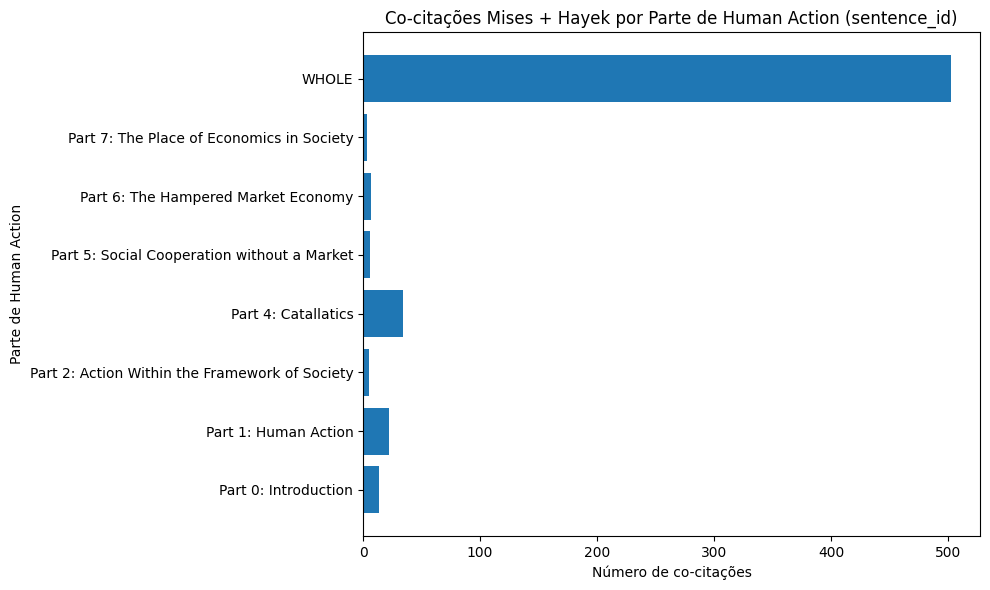

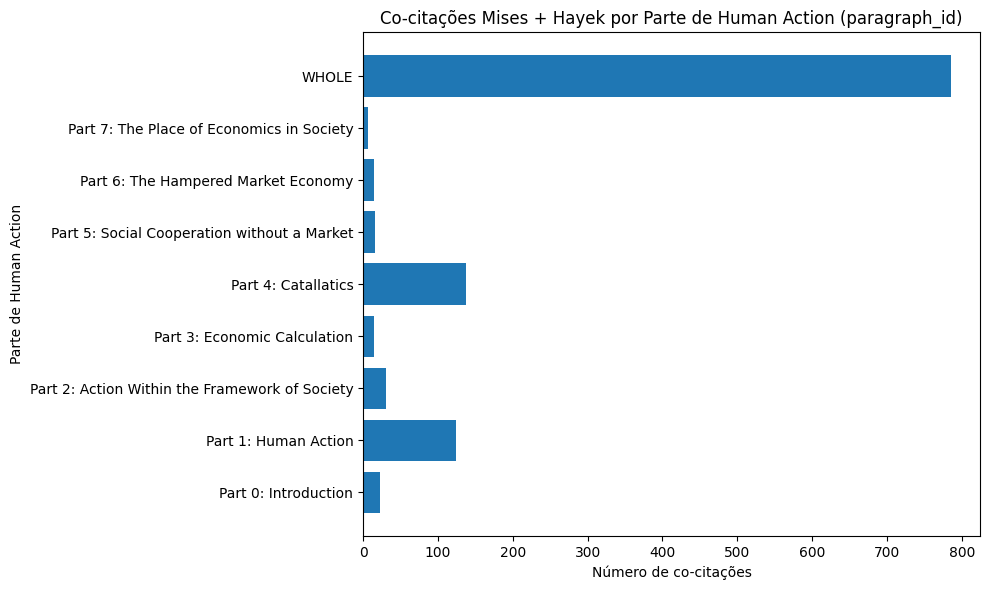

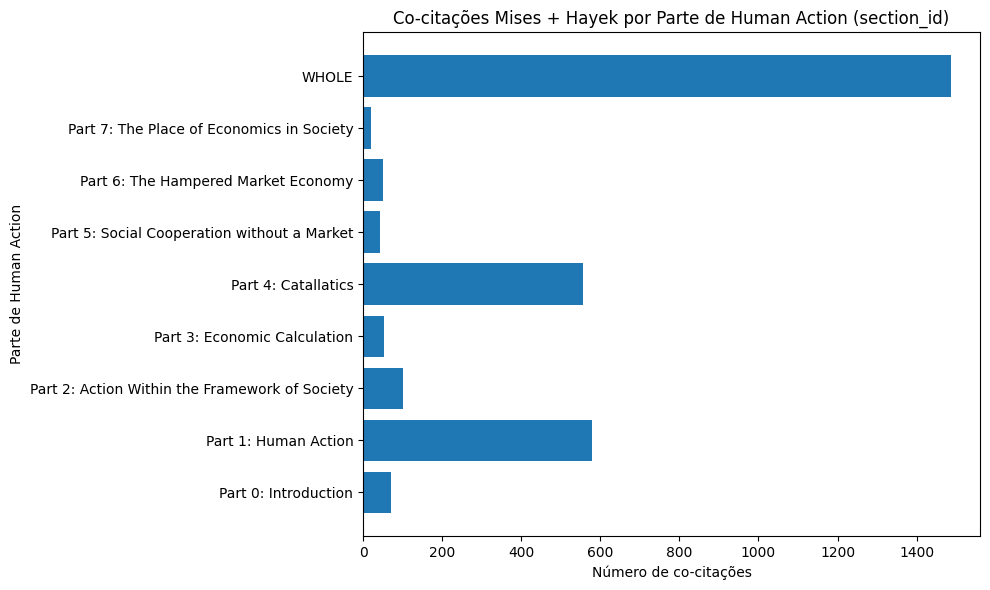

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_cocitation_histogram(mises_df, hayek_df, level):
    
    # 1. Encontrar interseção (co-citação)
    cocited_ids = set(mises_df[level]).intersection(set(hayek_df[level]))
    
    # 2. Filtrar citações de Mises nesses contextos
    mises_cocitations = mises_df[mises_df[level].isin(cocited_ids)]
    
    # 3. Contar co-citações por parte
    counts = (
        mises_cocitations
        .groupby(["human_action_part_number", "human_action_part_name"])
        .size()
        .reset_index(name="count")
    )
    
    # 4. Ordenar pelas partes do livro
    counts = counts.sort_values("human_action_part_number")
    
    # 5. Plot horizontal
    plt.figure(figsize=(10,6))
    plt.barh(counts["human_action_part_name"], counts["count"])
    
    plt.title(f"Co-citações Mises + Hayek por Parte de Human Action ({level})")
    plt.xlabel("Número de co-citações")
    plt.ylabel("Parte de Human Action")
    
    plt.tight_layout()
    plt.show()


# gerar os três gráficos
plot_cocitation_histogram(mises_citations_df, hayek_citations_df, "sentence_id")
plot_cocitation_histogram(mises_citations_df, hayek_citations_df, "paragraph_id")
plot_cocitation_histogram(mises_citations_df, hayek_citations_df, "section_id")

Análise Qualitativa

In [32]:
import pandas as pd

# Selecionar colunas necessárias de Mises
mises_df = mises_citations_df[
    [
        'paper_id',
        'sentence_id',
        'paragraph_id',
        'section_id',
        'human_action_chapter_number',
        'human_action_chapter_name',
        'human_action_part_number',
        'human_action_part_name',
        'context'
    ]
]

# Garantir apenas sentence_id do Hayek para detectar co-citação
hayek_df = hayek_citations_df[['sentence_id']].drop_duplicates()

# Co-citações na mesma sentença
co_citations = pd.merge(
    mises_df,
    hayek_df,
    on='sentence_id',
    how='inner'
)

# Tabela final
mises_hayek_sentence_co_citation_table = co_citations[
    [
        'paper_id',
        'sentence_id',
        'paragraph_id',
        'section_id',
        'human_action_chapter_number',
        'human_action_chapter_name',
        'human_action_part_number',
        'human_action_part_name',
        'context'
    ]
].drop_duplicates()

# Ordenar para facilitar leitura
mises_hayek_sentence_co_citation_table = mises_hayek_sentence_co_citation_table.sort_values(
    ['human_action_part_number', 'human_action_chapter_number', 'sentence_id']
)

mises_hayek_sentence_co_citation_table

,paper_id,sentence_id,paragraph_id,section_id,human_action_chapter_number,human_action_chapter_name,human_action_part_number,human_action_part_name,context
3,2058,_5HqWje6,_Pf83pua,_dEsdpUD,0,Chapter 0: Introduction,0,Part 0: Introduction,"Wealth-based definitions of the subject continued to dominate, but the idea of catallactics did not disappear: in the modern era, Ludwig von Mises (1949, p. 3), F. A. Hayek (1976, pp. 108 -109), and James Buchanan (1964, p. 217) have argued the case for a definition grounded in catallactics."
13,300,_7qU4t3N,_KUWsewG,_tsazGCS,0,Chapter 0: Introduction,0,Part 0: Introduction,"The interested reader is guided to Human Action (Mises 1998(Mises [1949]]), especially chapter one, sections 1, 2 and 4. 2 See also Mises (2005Mises ( [1957]], chapter 12) and Mises (1998 [1949], 11-12 and123-127); Hayek seems to share Mises's skepticism regarding psychology (see Hayek 1955, 39)."
9,104,_8hsdu4Z,_PK5Mxhj,_zd7zGzr,0,Chapter 0: Introduction,0,Part 0: Introduction,"Authoritarian law, whether imposed by kings or an elected representative assembly, involves the taking of wealth from relatively weak sub-groups in order to transfer it to relatively powerful sub-groups, or ""interest groups"" in reflection of the self-interest motives of the decision-making authorities (Benson 1990;1992b): the distinction is in terms of who gets what, ""not in the incentives and motives"" (Mises 1985a, p. 5; also see Hayek 1973, p. 3)."
6,717,_MAf7MJx,_V7aUyZ6,_f6eAJp7,0,Chapter 0: Introduction,0,Part 0: Introduction,"And his friend, the Austrian economist Friedrich von Hayek (1942Hayek ( , 1943Hayek ( , 1944)), wrote a series of articles on what he called scientism-the term he gave for the inappropriate use of the methods of the natural sciences in economics, while Mises (1966, p. 4) echoed Hayek's concerns with his criticisms of 'positivism'."
0,1979,_NEVh7mj,_2Rafa8h,_rAPytFn,0,Chapter 0: Introduction,0,Part 0: Introduction,"In this paper, I follow the theoretical arguments of Gordon Tullock and Anne Krueger to explain how Austrian economists (Mises 1990;Hayek 1980, chap. 2 and 3) solve the problem of corruption."
...,...,...,...,...,...,...,...,...,...
592,2692,_zCaUZdz,_5nfxPJU,_Uuj6pXB,WHOLE,WHOLE,WHOLE,WHOLE,"Austrian ideas specific to the firm have grown rather naturally out of the central body of Austrian thought with its focus on subjectivism, dispersed knowledge, disequilibrium, market process and entrepreneurship (von Mises 1949;Hayek 1945Hayek , 1978;;Rothbard 1962;Kirzner 1973;Lachmann 1977)."
231,567,_zTq9bEb,_N94EcBZ,NaN,WHOLE,WHOLE,WHOLE,WHOLE,(3) The third generation of the Austrian School of Economies includes promarket evolutionary theorists such asHayek (1944;1948;1978) while the second one includes subjectivist economists such asMises (1949).
513,2246,_zYpygaW,_sHvsQAe,_6NUXXTM,WHOLE,WHOLE,WHOLE,WHOLE,"The ASE, on other hand, always considered the entrepreneur as endogenous to the market process (von Hayek 1945;Kirzner 1973;von Mises 1998;Rothbard 2004) and the advancements in the theoretical debate have taken the Austrian comprehension on the term even closer to the one in P8 as in Foss and Klein (2012, 2015, 2018)."
336,1201,_zZWgyQQ,_SgNxqhK,_5vEhfQ4,WHOLE,WHOLE,WHOLE,WHOLE,"Communism, to reiterate, did away with private ownership of the means of production and replaced the market mechanism with central planning (Hayek, 1944(Hayek, , 1948;;Mises, 1949)."


In [35]:
import pandas as pd
import os
import re

# ==============================
# 1. Parágrafos que citam Mises
# ==============================

mises_paragraphs = mises_citations_df[
    [
        'paper_id',
        'paragraph_id',
        'section_id',
        'human_action_chapter_number',
        'human_action_chapter_name',
        'human_action_part_number',
        'human_action_part_name'
    ]
].drop_duplicates()

# ==============================
# 2. Parágrafos que citam Hayek
# ==============================

hayek_paragraphs = hayek_citations_df[['paragraph_id']].drop_duplicates()

# ==============================
# 3. Co-citação no nível de parágrafo
# ==============================

paragraph_co_citations = pd.merge(
    mises_paragraphs,
    hayek_paragraphs,
    on='paragraph_id',
    how='inner'
)

# ==============================
# 4. Unir sentenças para reconstruir parágrafo
# ==============================

sentences_df = pd.concat(
    [
        mises_citations_df[['paragraph_id','sentence_id','sentence_seq_number','context']],
        hayek_citations_df[['paragraph_id','sentence_id','sentence_seq_number','context']]
    ]
)

# Remover duplicatas da mesma sentença
sentences_df = sentences_df.drop_duplicates(subset='sentence_id')

# ==============================
# 5. Construir contexto completo do parágrafo
# ==============================

paragraph_context = (
    sentences_df
    .sort_values(['paragraph_id','sentence_seq_number'])
    .groupby('paragraph_id')['context']
    .apply(lambda x: "\n(...)\n".join(x))
    .reset_index()
)

# ==============================
# 6. Juntar contexto com co-citações
# ==============================

mises_hayek_paragraph_co_citation_table = pd.merge(
    paragraph_co_citations,
    paragraph_context,
    on='paragraph_id',
    how='left'
)

# ==============================
# 7. Ordenar tabela
# ==============================

mises_hayek_paragraph_co_citation_table = mises_hayek_paragraph_co_citation_table.sort_values(
    ['human_action_part_number','human_action_chapter_number','paragraph_id']
)

# ==============================
# 8. Salvar tabela completa
# ==============================

os.makedirs("../data/processed", exist_ok=True)

mises_hayek_paragraph_co_citation_table.to_csv(
    "../data/processed/mises_hayek_paragraph_co_citation.csv",
    index=False
)

# ==============================
# 9. Salvar um CSV por PART
# ==============================

output_dir = "../data/processed/mises_hayek_by_part"
os.makedirs(output_dir, exist_ok=True)

for (part_number, part_name), df_part in mises_hayek_paragraph_co_citation_table.groupby(
    ['human_action_part_number','human_action_part_name']
):

    safe_name = re.sub(r'[^\w\s-]', '', str(part_name)).replace(" ", "_")

    file_name = f"{output_dir}/part_{part_number}_{safe_name}.csv"

    df_part.to_csv(file_name, index=False)

print("Arquivos salvos por parte de Human Action.")

Arquivos salvos por parte de Human Action.
